In [1]:
import os
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
from maomao.dataset_description.graph_distribution_analysis import *

### Toxicity dataset composition and endpoint co-occurrence analysis

This notebook characterizes the curated peptide toxicity dataset by analyzing the distribution of toxicity endpoints, ambiguous annotations, and descriptor summaries. It computes endpoint-level composition, identifies peptides associated with multiple toxicity categories, and visualizes toxicity endpoint co-occurrence through summary plots and heatmaps.


- Read data

In [2]:
df_pivote_class = pd.read_csv("../../processed_data/processed_data/maomao_sequence_pivot.csv")

- Graph of number of effects per sequences

In [3]:
combination_counts, cooccurrence_matrix, df_top_level = compute_top_level_toxicity_summary(df=df_pivote_class)

- Plot dataset composition by endpoint

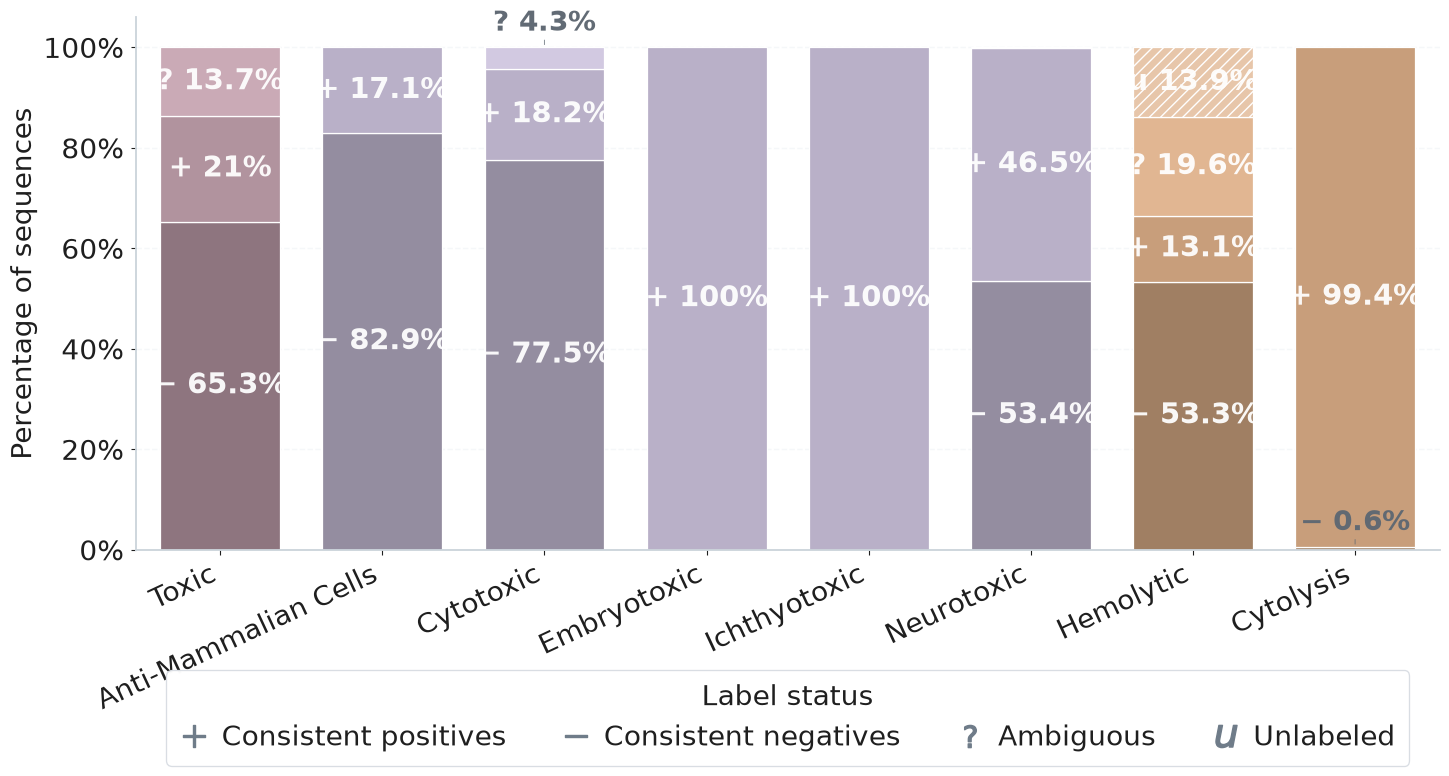

In [4]:
colors = {
    "toxic": "#C5A3B0",
    "cytotoxic": "#CEC4DE",
    "neurotoxic": "#CEC4DE",
    "embryotoxic": "#CEC4DE",
    "ichthyotoxic": "#CEC4DE",
    "hemolytic": "#DEB089",
    "cytolysis": "#DEB089",
    "anti_mammalian_cells": "#CEC4DE",
}

fig, ax, summary_counts, summary_pct = (
    plot_dataset_composition_by_endpoint_vertical(
        df_main=df_pivote_class,
        title_fontsize=18,
        tick_fontsize=20,
        label_fontsize=20,
        annot_fontsize=21,
        legend_fontsize=20,
        legend_title_fontsize=20,
        legend_loc="upper center",
        legend_bbox_to_anchor=(0.5, -0.2),
        figsize=(15, 8),
        endpoint_colors=colors,
        bar_width=0.85,
        small_label_threshold=6.0,
        hide_label_below_pct=0.4,
        outside_label_offset=2.0,
        bold_fonts=False,
    )
)
fig.savefig("plot_dataset_composition_by_endpoint_horizontal.png", dpi=800)

- Plot effect cooccurrence

In [5]:
results = compute_effect_cooccurrence(
    df_pivote_class,
    verbose=True,
)

cooccurrence_matrix = results["cooccurrence_matrix"]
row_totals = results["row_totals"]
effect_binary = results["effect_binary"]
summary = results["summary"]

cooccurrence_matrix

Sequences with at least one positive endpoint: 9,466
Sequences with multiple positive endpoints: 4,808
Percentage among positive sequences: 50.79%


cooccurring_endpoint,anti_mammalian_cells,cytotoxic,embryotoxic,ichthyotoxic,neurotoxic,hemolytic,cytolysis
endpoint,,,,,,,
anti_mammalian_cells,3664,456,0,0,7,773,117
cytotoxic,456,4606,0,3,19,4180,247
embryotoxic,0,0,2,0,0,0,0
ichthyotoxic,0,3,0,5,0,2,5
neurotoxic,7,19,0,0,1481,8,12
hemolytic,773,4180,0,2,8,4754,151
cytolysis,117,247,0,5,12,151,341


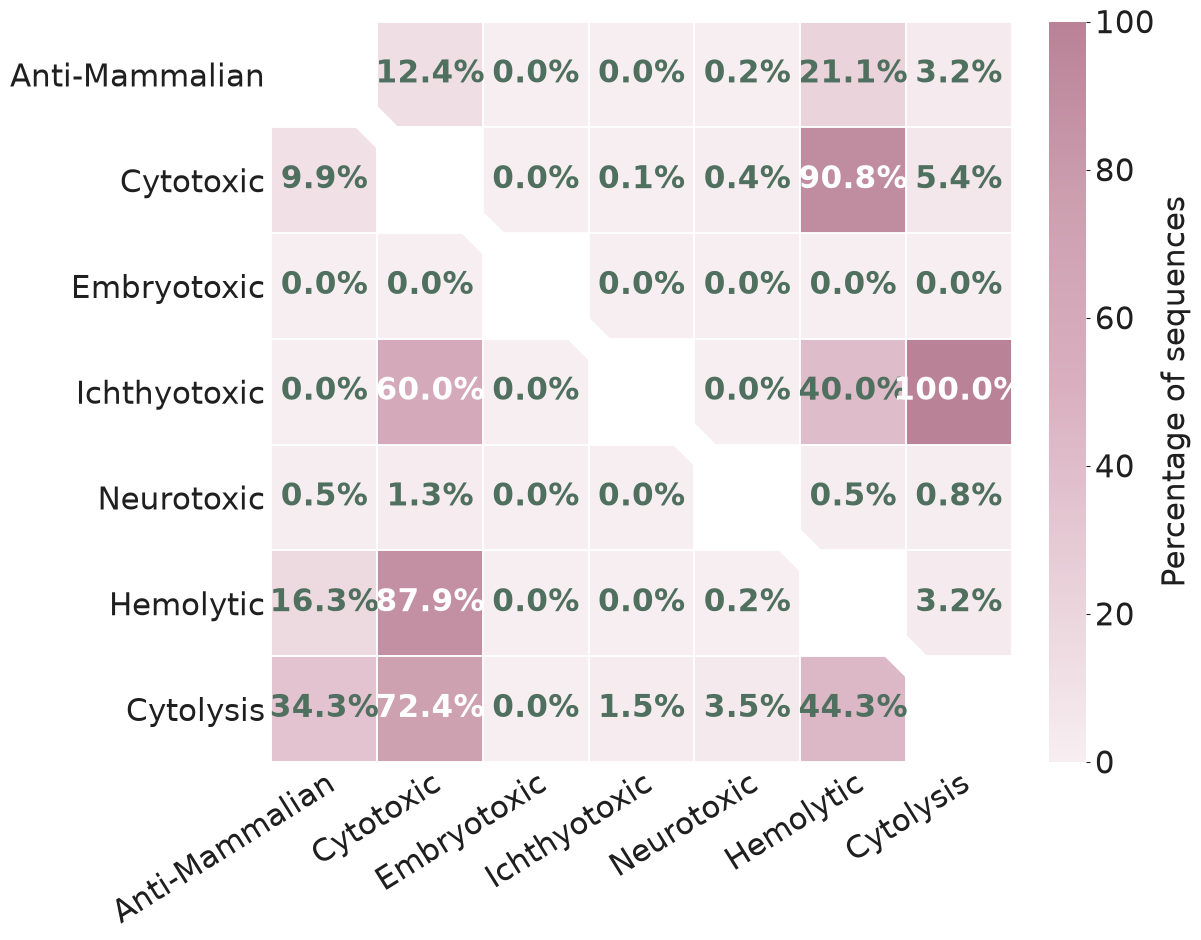

In [6]:
fig, ax, im, cbar, overlap_pct = plot_all_effects_cooccurrence_heatmap(
    cooccurrence_matrix=cooccurrence_matrix,
    row_totals=row_totals,
    cbar_label="Percentage of sequences",
    #save_path="all_effects_cooccurrence_heatmap.png",
    figsize=(12, 9.5)
)